In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"C:\Users\ssita\pythonclass\project2.csv") #--------------------data is being read from the csv file and stored in a variable called df
df

,order_id,product_name,category,quantity,unit_price,total_price,salesperson,region,order_date,customer_name
0,1,Laptop Pro 15,Electronics,2.0,1200.00,2400.0,Alice Johnson,North,1/3/2024,John Smith
1,2,Wireless Mouse,Electronics,5.0,25.50,127.5,Bob Lee,South,1/5/2024,Emma Davis
2,3,Office Chair,Furniture,NaN,350.00,NaN,Carol White,East,1/7/2024,Liam Brown
3,4,Notebook Set,Stationery,10.0,8.99,89.9,David Kim,West,1/9/2024,NaN
4,5,USB-C Hub,Electronics,3.0,45.00,135.0,Alice Johnson,North,1/11/2024,Olivia Wilson
5,6,Standing Desk,Furniture,1.0,NaN,NaN,Bob Lee,South,1/13/2024,NaN
6,7,Mechanical Keyboard,Electronics,2.0,110.00,220.0,Carol White,East,1/15/2024,Ava Taylor
7,8,Monitor 27inch,Electronics,1.0,350.00,350.0,NaN,West,1/17/2024,Sophia Anderson
8,9,Pen Drive 64GB,Accessories,8.0,12.00,96.0,David Kim,North,1/19/2024,James Thomas
9,10,Desk Lamp,Furniture,4.0,30.00,120.0,Alice Johnson,South,NaN,William Jackson


In [4]:
df.info() #--------------------this line of code is used to get information about the dataframe, such as the number of rows and columns, data types, and memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       50 non-null     int64  
 1   product_name   50 non-null     object 
 2   category       50 non-null     object 
 3   quantity       46 non-null     float64
 4   unit_price     46 non-null     float64
 5   total_price    42 non-null     float64
 6   salesperson    45 non-null     object 
 7   region         46 non-null     object 
 8   order_date     47 non-null     object 
 9   customer_name  39 non-null     object 
dtypes: float64(3), int64(1), object(6)
memory usage: 4.0+ KB


In [5]:
missing_values =df.isnull().sum() #--------------------this line of code is used to check for missing values in the dataframe and count the number of missing values in each column
print(missing_values)

order_id          0
product_name      0
category          0
quantity          4
unit_price        4
total_price       8
salesperson       5
region            4
order_date        3
customer_name    11
dtype: int64


In [6]:
missing_values_percent =(df.isnull().sum() / len(df)) * 100 #--------------------this line of code is used to calculate the percentage of missing values in each column by dividing the number of missing values by the total number of rows in the dataframe and multiplying by 100
print(missing_values_percent)

order_id          0.0
product_name      0.0
category          0.0
quantity          8.0
unit_price        8.0
total_price      16.0
salesperson      10.0
region            8.0
order_date        6.0
customer_name    22.0
dtype: float64


In [9]:
print(missing_values_percent.round(2)) #--------------------this line of code is used to round the percentage of missing values to 2 decimal places for better readability

order_id          0.0
product_name      0.0
category          0.0
quantity          8.0
unit_price        8.0
total_price      16.0
salesperson      10.0
region            8.0
order_date        6.0
customer_name    22.0
dtype: float64


In [11]:
missing_columns = df.columns[df.isnull().any()].tolist() #--------------------this line of code is used to identify the columns that have missing values by checking for any null values in each column and creating a list of those column names
print("missing columns:", len(missing_columns)) #--------------------this line of code is used to print the number of columns that have missing values by calculating the length of the list of missing columns and printing it with a descriptive message
print(missing_columns) #--------------------this line of code is used to print the list of column names that have missing values for further analysis and reference

missing columns: 7
['quantity', 'unit_price', 'total_price', 'salesperson', 'region', 'order_date', 'customer_name']


In [13]:
missing_rows = df[df.isnull().any(axis=1)] #--------------------this line of code is used to identify the rows that have missing values by checking for any null values across all columns in each row and creating a new dataframe that contains only those rows with missing values
print("total missing rows", len(missing_rows)) #--------------------this line of code is used to print the number of rows that have missing values by calculating the length of the dataframe of missing rows and printing it with a descriptive message
missing_rows


total missing rows 27


,order_id,product_name,category,quantity,unit_price,total_price,salesperson,region,order_date,customer_name
2,3,Office Chair,Furniture,NaN,350.00,NaN,Carol White,East,1/7/2024,Liam Brown
3,4,Notebook Set,Stationery,10.0,8.99,89.9,David Kim,West,1/9/2024,NaN
5,6,Standing Desk,Furniture,1.0,NaN,NaN,Bob Lee,South,1/13/2024,NaN
7,8,Monitor 27inch,Electronics,1.0,350.00,350.0,NaN,West,1/17/2024,Sophia Anderson
9,10,Desk Lamp,Furniture,4.0,30.00,120.0,Alice Johnson,South,NaN,William Jackson
11,12,Webcam HD,Electronics,NaN,60.00,NaN,Carol White,West,1/25/2024,Benjamin Harris
12,13,A4 Paper Ream,Stationery,20.0,6.50,130.0,David Kim,North,1/27/2024,NaN
14,15,Printer Ink,Accessories,6.0,18.00,108.0,NaN,East,1/31/2024,Henry Garcia
17,18,Ergonomic Mouse,Electronics,4.0,NaN,NaN,David Kim,South,2/6/2024,NaN
19,20,Cable Organizer,Accessories,15.0,5.00,75.0,Bob Lee,NaN,2/10/2024,Harper Lewis


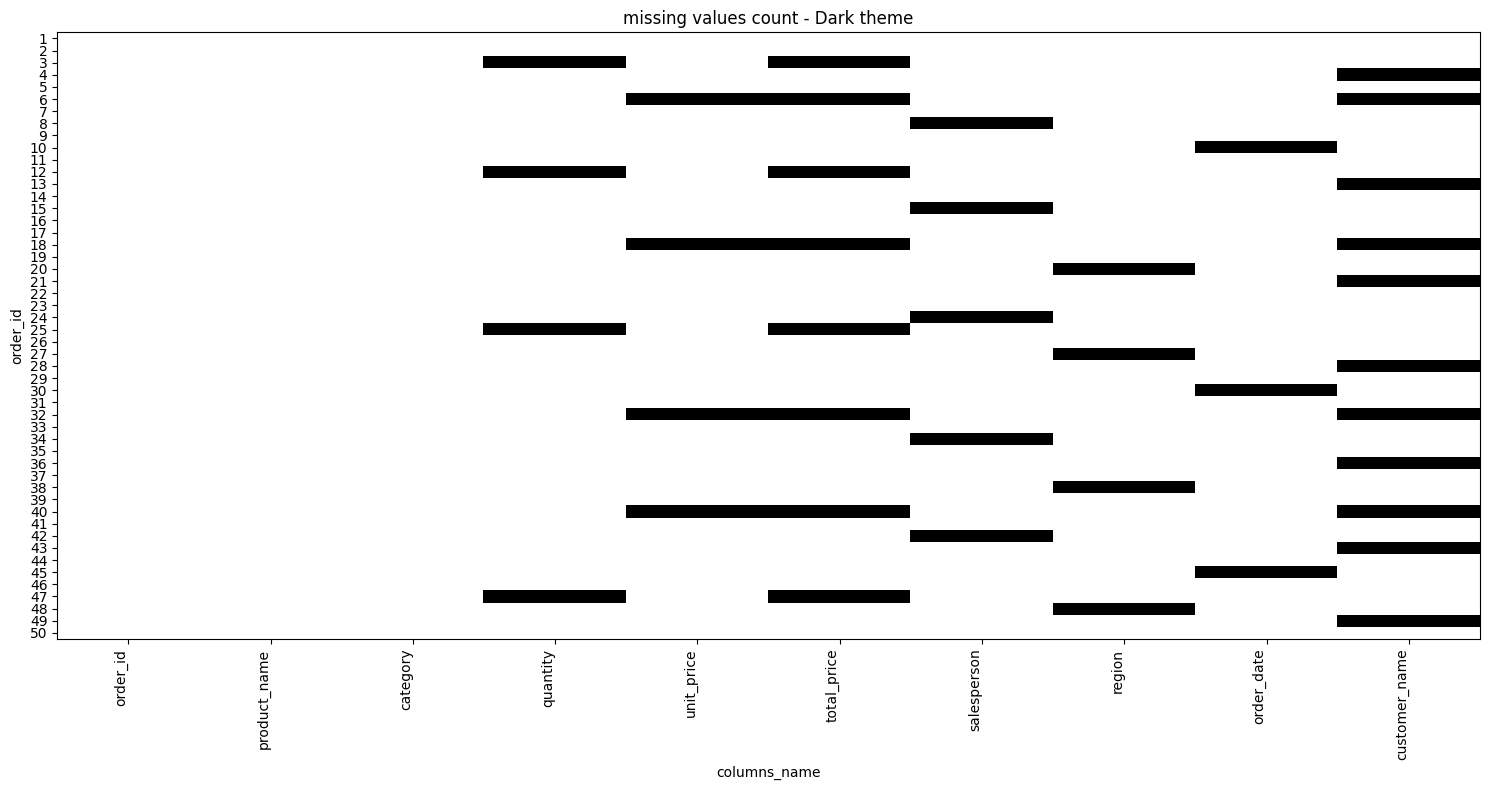

In [16]:
plt.figure(figsize=(15 , 8)) #--------------------this line of code is used to set the size of the plot to 13 inches in width and 6 inches in height for better visualization
plt.title("missing values count - Dark theme") #--------------------this line of code is used to set the title of the plot to "missing values count - Dark theme" to provide context and information about the plot
plt.imshow(df.isnull(), aspect="auto", cmap="Greys", interpolation="none") #--------------------this line of code is used to create a heatmap visualization of the missing values in the dataframe by using the isnull() function to identify missing values, setting the aspect ratio to "auto" for better display, and using the "Greys" colormap to differentiate between missing and non-missing values
plt.xticks(range(len(df.columns)), df.columns, rotation =90, ha="right") #--------------------this line of code is used to set the x-axis ticks to correspond to the column names of the dataframe, rotate the labels 90 degrees for better readability, and align them to the right
plt.yticks(range(len(df)), df["order_id"]) #--------------------this line of code is used to set the y-axis ticks to correspond to the row indices of the dataframe and label them with the "order_id" column for better identification of each row
plt.xlabel("columns_name") #--------------------this line of code is used to set the label for the x-axis to "columns" to provide context for the data being visualized
plt.ylabel("order_id") #--------------------this line of code is used to set the label for the y-axis to "order_id" to provide context for the data being visualized
plt.tight_layout() #--------------------this line of code is used to automatically adjust the layout of the plot to ensure that all elements are properly displayed without overlapping or being cut off
plt.show() #--------------------this line of code is used to display the plot on the screen